# Antispoofing

In this homework, you will develop a countermeasure against deepfakes and then try to explain it using various XAI techniques.

More specifically, you will implement and train a Countermeasure (CM) system on the Logical Access partition of the [ASVSpoof 2019 Dataset](https://datashare.ed.ac.uk/handle/10283/3336) ([Kaggle Link](https://www.kaggle.com/datasets/awsaf49/asvpoof-2019-dataset)). You may find the [ASVspoof 2019 evaluation plan](https://www.asvspoof.org/asvspoof2019/asvspoof2019_evaluation_plan.pdf) useful.

For the CM, we choose [LightCNN (LCCN)](https://arxiv.org/abs/1511.02683) that once achieved the top place in the competition. We will follow the Speech Technology Center (STC) [paper](https://arxiv.org/abs/1904.05576).

**Hints**:

1. Use STFT (FFT in the paper) as front-end.

2. The dropout layer is put before the last batch norm.

## Dataset [0.5 pts]

We want to train a neural network to predict if the input audio is real or fake. To do so, we need a dataset first. In this homework, we will work with [ASVspoof19](https://arxiv.org/pdf/1911.01601.pdf).

Create a `Dataset` class that downloads the dataset, parses its metadata and, given index $i$, returns $i$-th object of the dataset. Do not forget to preprocess audio for LCNN (calculate stft, etc.).

In [1]:
import torch
import torch.nn as nn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

import torchaudio
import torchaudio.functional as F
import torchaudio.transforms as T

from IPython.display import Audio
from tqdm import tqdm

In [8]:
# CONFIG

ROOT = 'asvpoof-2019-dataset/LA/LA/'

FLAC_DIR_TRAIN = os.path.join(ROOT, "ASVspoof2019_LA_train/flac")
STFT_DIR_TRAIN = "working/ASVspoof2019_LA_train/stft"
PROTOCOL_TRAIN = os.path.join(ROOT, "ASVspoof2019_LA_cm_protocols/ASVspoof2019.LA.cm.train.trn.txt")

FLAC_DIR_DEV = os.path.join(ROOT, "ASVspoof2019_LA_dev/flac")
STFT_DIR_DEV = "working/ASVspoof2019_LA_dev/stft"
PROTOCOL_DEV = os.path.join(ROOT, "ASVspoof2019_LA_cm_protocols/ASVspoof2019.LA.cm.dev.trl.txt")

FLAC_DIR_EVAL = os.path.join(ROOT, "ASVspoof2019_LA_eval/flac")
STFT_DIR_EVAL = "working/ASVspoof2019_LA_eval/stft"
PROTOCOL_EVAL = os.path.join(ROOT, "ASVspoof2019_LA_cm_protocols/ASVspoof2019.LA.cm.eval.trl.txt")

os.makedirs(STFT_DIR_TRAIN, exist_ok=True)
os.makedirs(STFT_DIR_DEV, exist_ok=True)
os.makedirs(STFT_DIR_EVAL, exist_ok=True)

SAMPLE_RATE = 16000
N_FFT = 512
HOP = 160
WIN = 400
MAX_FRAMES = 400

stft = T.Spectrogram(
    n_fft=N_FFT,
    hop_length=HOP,
    win_length=WIN,
    power=None
)

In [9]:
print(f"Количество flac в train: {len(os.listdir(FLAC_DIR_TRAIN))}")
print(f"Количество flac в dev: {len(os.listdir(FLAC_DIR_DEV))}")
print(f"Количество flac в eval: {len(os.listdir(FLAC_DIR_EVAL))}")

Количество flac в train: 25380
Количество flac в dev: 24986
Количество flac в eval: 71933


In [10]:
LA_cm_protocol = pd.read_csv(PROTOCOL_TRAIN, 
    sep=' ', 
    header=None, 
    names=['SpeakerID', 'UtteranceID', 'UtteranceType?', 'SpoofAlgoId', 'IsSpoofed'])

In [11]:
LA_cm_protocol.head(2)

,SpeakerID,UtteranceID,UtteranceType?,SpoofAlgoId,IsSpoofed
0,LA_0079,LA_T_1138215,-,-,bonafide
1,LA_0079,LA_T_1271820,-,-,bonafide


In [12]:
print(f"Количество bonafide = {(LA_cm_protocol['IsSpoofed'] == 'bonafide').sum()}")
print(f"Количество spoof = {(LA_cm_protocol['IsSpoofed'] == 'spoof').sum()}")

Количество bonafide = 2580
Количество spoof = 22800


In [13]:
protocol_dev = pd.read_csv(PROTOCOL_DEV, 
    sep=' ', 
    header=None, 
    names=['SpeakerID', 'UtteranceID', 'UtteranceType?', 'SpoofAlgoId', 'IsSpoofed'])

In [14]:
protocol_dev_5000 = protocol_dev[:5000]
set_of_dev_utt = set(protocol_dev_5000['UtteranceID'])

In [15]:
print(f"Количество bonafide = {(protocol_dev_5000['IsSpoofed'] == 'bonafide').sum()}")
print(f"Количество spoof = {(protocol_dev_5000['IsSpoofed'] == 'spoof').sum()}")

Количество bonafide = 2548
Количество spoof = 2452


In [16]:
protocol_eval = pd.read_csv(PROTOCOL_EVAL, 
    sep=' ', 
    header=None, 
    names=['SpeakerID', 'UtteranceID', 'UtteranceType?', 'SpoofAlgoId', 'IsSpoofed'])

In [17]:
protocol_eval_5000 = protocol_eval[:5000]
set_of_eval_utt = set(protocol_eval_5000['UtteranceID'])

In [18]:
print(f"Количество bonafide = {(protocol_eval_5000['IsSpoofed'] == 'bonafide').sum()}")
print(f"Количество spoof = {(protocol_eval_5000['IsSpoofed'] == 'spoof').sum()}")

Количество bonafide = 561
Количество spoof = 4439


In [19]:
def preprocessing(FLAC_DIR, OUT_DIR):
    """
    Переводим в stft
    """
    for name in tqdm(os.listdir(FLAC_DIR)):
        if not name.endswith(".flac"):
            continue

        path = os.path.join(FLAC_DIR, name)
        wav, sr = torchaudio.load(path)
    
        if sr != SAMPLE_RATE:
            wav = F.resample(wav, sr, SAMPLE_RATE)
    
        wav = wav.mean(dim=0)
    
        spec = stft(wav)
        spec = torch.abs(spec)
        spec = torch.log(spec + 1e-6)
        spec = spec - spec.mean()
        
        if spec.size(1) < MAX_FRAMES:
            pad = MAX_FRAMES - spec.size(1)
            spec = torch.nn.functional.pad(spec, (0, pad))
        else:
            start = torch.randint(0, spec.size(1) - MAX_FRAMES + 1, (1,)).item()
            spec = spec[:, start:start+MAX_FRAMES]

    
        spec = spec.unsqueeze(0) # [1, F, T]
    
        out_path = os.path.join(OUT_DIR, name.replace(".flac", ".pt"))
        torch.save(spec, out_path)

In [20]:
preprocessing(FLAC_DIR_TRAIN, STFT_DIR_TRAIN)

100%|██████████████████████████████████████████████████████████████████████████████████████| 25380/25380 [01:11<00:00, 352.63it/s]


In [21]:
def preprocessing_dev(FLAC_DIR, OUT_DIR):
    """
    Переводим в stft
    """
    for name in tqdm(os.listdir(FLAC_DIR)): 
        if not name.endswith(".flac") or (name[:-5] not in set_of_eval_utt and name[:-5] not in set_of_dev_utt):   # для dev и eval берем 5000 аудио
            continue

        path = os.path.join(FLAC_DIR, name)
        wav, sr = torchaudio.load(path)
    
        if sr != SAMPLE_RATE:
            wav = F.resample(wav, sr, SAMPLE_RATE)
    
        wav = wav.mean(dim=0)
    
        spec = stft(wav)
        spec = torch.abs(spec)
        spec = torch.log(spec + 1e-6)
        spec = spec - spec.mean()
        
        if spec.size(1) < MAX_FRAMES:
            pad = MAX_FRAMES - spec.size(1)
            spec = torch.nn.functional.pad(spec, (0, pad))
        else:
            start = (spec.size(1) - MAX_FRAMES) // 2
            spec = spec[:, start:start+MAX_FRAMES]
    
        spec = spec.unsqueeze(0) # [1, F, T]
    
        out_path = os.path.join(OUT_DIR, name.replace(".flac", ".pt"))
        torch.save(spec, out_path)

In [22]:
preprocessing_dev(FLAC_DIR_DEV, STFT_DIR_DEV) # берем 5000

100%|█████████████████████████████████████████████████████████████████████████████████████| 24986/24986 [00:11<00:00, 2133.03it/s]


In [23]:
preprocessing_dev(FLAC_DIR_EVAL, STFT_DIR_EVAL) # берем 5000
len(os.listdir(STFT_DIR_EVAL))

100%|█████████████████████████████████████████████████████████████████████████████████████| 71933/71933 [00:14<00:00, 4865.36it/s]


5000

In [24]:
class Dataset(torch.utils.data.Dataset):
    
    def __init__(self, stft_dir, metadata_path, mode='train'):
        self.stft_dir = stft_dir
        self.mode = mode
        self.protocol = self.get_protocol(metadata_path)
        
        self.label_map = {"bonafide": 1, "spoof": 0}

    def get_protocol(self, metadata_path):
        protocol = pd.read_csv(
            metadata_path,
            sep=' ',
            header=None,
            names=['SpeakerID', 'UtteranceID', 'UtteranceType?', 'SpoofAlgoId', 'IsSpoofed'])
        
        protocol = protocol[['UtteranceID', 'IsSpoofed']]

        if self.mode == 'dev':
            protocol = protocol[protocol['UtteranceID'].isin(set_of_dev_utt)] 
        elif self.mode == 'eval':
            protocol = protocol[protocol['UtteranceID'].isin(set_of_eval_utt)] 
        
        return protocol
        
    def __len__(self):
        return len(self.protocol)

    def __getitem__(self, idx):
        
        row = self.protocol.iloc[idx]
        utt_id = row['UtteranceID']
        label = row['IsSpoofed']

        spec = torch.load(
            os.path.join(self.stft_dir, utt_id + ".pt")
        )

        return spec, self.label_map[label]

**Hint**: when working in Kaggle, it is easier and faster to use dataset as kaggle input. We can use it directly or add a symlink to a local dir using `ln -s`.
**Hint**: it might be easier to do this homework in Kaggle, since model training may take some time

Create train/eval dataset and dataloaders:

In [25]:
dataset_train = Dataset(STFT_DIR_TRAIN, PROTOCOL_TRAIN)

dl_train = torch.utils.data.DataLoader(
    dataset_train,
    batch_size=32,
    shuffle=True,
    num_workers=4,
    pin_memory=True
)

In [26]:
dataset_dev = Dataset(STFT_DIR_DEV, PROTOCOL_DEV, mode='dev')

dl_dev = torch.utils.data.DataLoader(
    dataset_dev,
    batch_size=32,
    shuffle=False,
    num_workers=4
)

In [27]:
dataset_eval = Dataset(STFT_DIR_EVAL, PROTOCOL_EVAL, mode='eval')

dl_eval = torch.utils.data.DataLoader(
    dataset_eval,
    batch_size=32,
    shuffle=False,
    num_workers=4
)

Visualize one object, just to check that all is fine:

In [28]:
x, y = next(iter(dl_eval))

print("x.shape:", x.shape)   # ожидаем [B, 1, F, T]
print("y.shape:", y.shape)   # [B]
print("labels:", y[:32])

x.shape: torch.Size([32, 1, 257, 400])
y.shape: torch.Size([32])
labels: tensor([0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0])


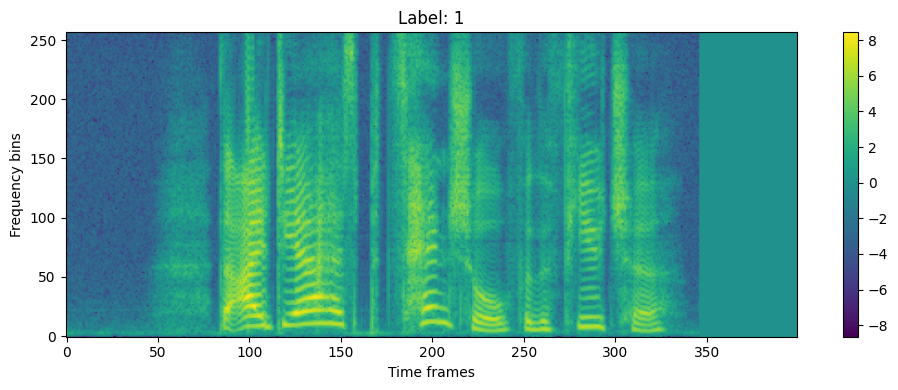

In [29]:
spec, label = dataset_train[0]
spec = spec.squeeze(0)  # [F, T]

plt.figure(figsize=(10, 4))
plt.imshow(
    spec.numpy(),
    origin="lower",
    aspect="auto"
)
plt.colorbar()
plt.title(f"Label: {label}")
plt.xlabel("Time frames")
plt.ylabel("Frequency bins")
plt.tight_layout()
plt.show()

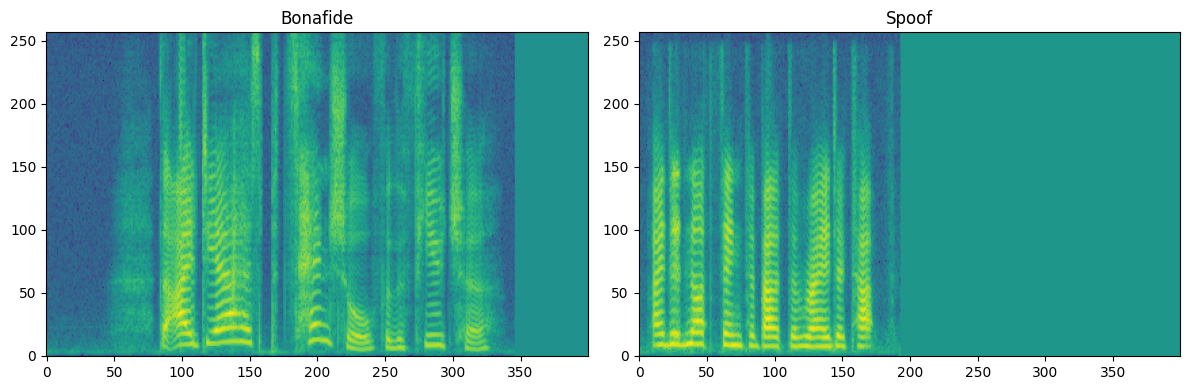

In [30]:
def get_example(ds, target_label):
    for i in range(len(ds)):
        x, y = ds[i]
        if y == target_label:
            return x.squeeze(0)

bon = get_example(dataset_train, 1)
spo = get_example(dataset_train, 0)

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.imshow(bon, origin="lower", aspect="auto")
plt.title("Bonafide")

plt.subplot(1, 2, 2)
plt.imshow(spo, origin="lower", aspect="auto")
plt.title("Spoof")

plt.tight_layout()
plt.show()

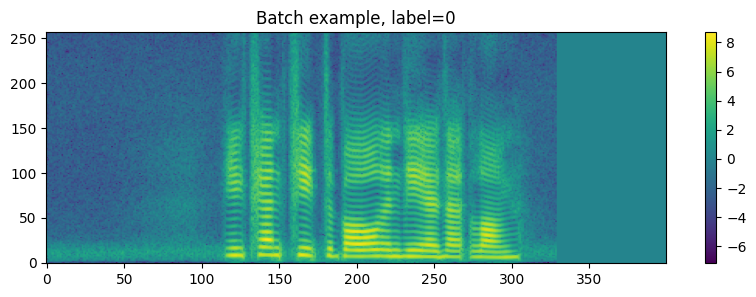

In [31]:
x, y = next(iter(dl_train))

plt.figure(figsize=(10, 3))
plt.imshow(
    x[0, 0].cpu(),
    origin="lower",
    aspect="auto"
)
plt.title(f"Batch example, label={y[0].item()}")
plt.colorbar()
plt.show()

In [32]:
print("mean:", x.mean().item())
print("std :", x.std().item())
print("min :", x.min().item())
print("max :", x.max().item())

mean: 0.10592106729745865
std : 2.2487614154815674
min : -9.876421928405762
max : 9.360387802124023


In [33]:
x, y = next(iter(dl_train))
print(x.shape)  # [32, 1, F, T]
print(y.shape)  # [32]
print(y.unique())  

torch.Size([32, 1, 257, 400])
torch.Size([32])
tensor([0, 1])


## Loss function [0.5 pts]

In the lecture, we saw different softmax losses and the motivation behind them for the ASV task. However, they can also be used for any classification task, such as synthesized speech detection. The papers suggest to use A(M)-Softmax or Cross-Entropy. The STC paper argues that A-Softmax is better.

(a) Explain what are the benefits of A-softmax over cross-entropy according to the STC paper?

(b) Analyse the [NII paper](https://arxiv.org/pdf/2103.11326) and explain if complicated Softmax is actually needed to achieve good EER or we can go with Cross Entropy.

**Answer**: your answer here...

Following tha NII paper, we will continue with Cross Entropy

In [34]:
from torch import nn

criterion = nn.CrossEntropyLoss()

## Evaluation metric [0.5 pts]

We will use equal error rate as the primary evaluation metric. The code for calculating metrics is provided by the ASVspoof itself. We just need to write a wrapper. Given model logits and labels, calculate EER using the ASVspoof functions.

Your model returns two probas: [spoof_proba, bona_proba]. Be careful with the EER metric and recal how ROC curve is computed to ensure that you do not make a mistake.

In [35]:
# download asvspoof metric calculation functions
!wget https://raw.githubusercontent.com/markovka17/dla/refs/heads/2023/hw5_as/calculate_eer.py

--2026-05-09 11:16:56--  https://raw.githubusercontent.com/markovka17/dla/refs/heads/2023/hw5_as/calculate_eer.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.110.133, 185.199.111.133, 185.199.108.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.110.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 14555 (14K) [text/plain]
Saving to: ‘calculate_eer.py’

calculate_eer.py    100%[===================>]  14.21K  --.-KB/s    in 0.005s  

2026-05-09 11:16:57 (3.04 MB/s) - ‘calculate_eer.py’ saved [14555/14555]



In [36]:
from calculate_eer import compute_eer

def get_eer(logits, labels):
    probs = torch.softmax(logits, dim=1)
    scores = probs[:, 1].detach().cpu().numpy()
    labels = labels.detach().cpu().numpy()

    bonafide_scores = scores[labels == 1]
    spoof_scores    = scores[labels == 0]

    eer, _ = compute_eer(bonafide_scores, spoof_scores)
    return eer

## LCNN Implementation [6.0 pts]

Create a `LCNN` class for the model architecture.

In [37]:
class MFM(nn.Module):
    def __init__(self, out_ch):
        super().__init__()
        self.out_ch = out_ch

    def forward(self, x):

        c = self.out_ch
        return torch.max(x[:,:c], x[:,c:])
        
class LCNN(nn.Module):
    def __init__(self, num_classes=2):
        super().__init__()

        self.conv1 = nn.Conv2d(1, 64 * 2, kernel_size=5, stride=1, padding=2)
        self.mfm1 = MFM(64)
        self.bn1  = nn.BatchNorm2d(64)
        self.pool1 = nn.MaxPool2d(2, 2)

        self.conv2_1x1 = nn.Conv2d(64, 64 * 2, kernel_size=1)
        self.mfm2_1x1 = MFM(64)
        self.bn2_1x1 = nn.BatchNorm2d(64)

        self.conv3 = nn.Conv2d(64, 128 * 2, kernel_size=3, padding=1)
        self.mfm3 = MFM(128)
        self.bn3  = nn.BatchNorm2d(128)
        self.pool3 = nn.MaxPool2d(2, 2)

        self.conv4_1x1 = nn.Conv2d(128, 128 * 2, kernel_size=1)
        self.mfm4_1x1  = MFM(128)
        self.bn4_1x1   = nn.BatchNorm2d(128)

        self.conv5 = nn.Conv2d(128, 64 * 2, kernel_size=3, padding=1)
        self.mfm5 = MFM(64)
        self.bn5 = nn.BatchNorm2d(64)
        self.pool5 = nn.MaxPool2d(2, 2)

        self.gap = nn.AdaptiveAvgPool2d((1, 1))

        self.fc1 = nn.Linear(64, 128 * 2)
        self.mfm_fc1 = MFM(128)

        self.dropout = nn.Dropout(0.3)
        self.bn_fc1 = nn.BatchNorm1d(128)

        self.fc2 = nn.Linear(128, num_classes)

    def forward(self, x):
        # x: [B, 1, F, T]
        x = self.conv1(x)
        x = self.mfm1(x)
        x = self.bn1(x)
        x = self.pool1(x)
    
        x = self.conv2_1x1(x)
        x = self.mfm2_1x1(x)
        x = self.bn2_1x1(x)
    
        x = self.conv3(x)
        x = self.mfm3(x)
        x = self.bn3(x)
        x = self.pool3(x)
    
        x = self.conv4_1x1(x)
        x = self.mfm4_1x1(x)
        x = self.bn4_1x1(x)
    
        x = self.conv5(x)
        x = self.mfm5(x)
        x = self.bn5(x)
        x = self.pool5(x)
    
        x = self.gap(x)              # [B, 64, 1, 1]
        x = x.view(x.size(0), -1)    # [B, 64]
    
        x = self.fc1(x)
        x = self.mfm_fc1(x)
        x = self.dropout(x)
        x = self.bn_fc1(x)
    
        x = self.fc2(x)              # [B, num_classes]
        return x

In [38]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [39]:
model = LCNN().to(device)

In [40]:
# double-check that it runs (do eval mode)
x = torch.randn(8, 1, 257, 400).to(device)
y = model(x)

print(y.shape)  # [8, 2]

torch.Size([8, 2])


In [41]:
def test_single_pass(model, dataloader, device, num_batches=10):
    """Быстрый тестовый проход без оптимизации"""
    model.eval()
    losses = []
    
    with torch.no_grad():
        for batch_idx, (inputs, targets) in enumerate(dataloader):
            if batch_idx >= num_batches:
                break
            
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model(inputs)
            
            # Просто проверяем forward pass
            print(f'Batch {batch_idx}: Input shape: {inputs.shape}, Output shape: {outputs.shape}')
    
    print(f"Tested {min(num_batches, len(dataloader))} batches successfully!")

# Быстрая проверка
test_single_pass(model, dl_train, device, num_batches=5)

Batch 0: Input shape: torch.Size([32, 1, 257, 400]), Output shape: torch.Size([32, 2])
Batch 1: Input shape: torch.Size([32, 1, 257, 400]), Output shape: torch.Size([32, 2])
Batch 2: Input shape: torch.Size([32, 1, 257, 400]), Output shape: torch.Size([32, 2])
Batch 3: Input shape: torch.Size([32, 1, 257, 400]), Output shape: torch.Size([32, 2])
Batch 4: Input shape: torch.Size([32, 1, 257, 400]), Output shape: torch.Size([32, 2])
Tested 5 batches successfully!


Write the train loop. Since it may take some time, we advise you to save your checkpoints after each epoch to load it back if needed.

Plot EER vs epoch and loss vs epoch curves

In [47]:
def train_one_epoch(model, dataloader, criterion, optimizer, scheduler, device):
    model.train()

    running_loss = 0.0
    all_logits = []
    all_labels = []

    for x, y in tqdm(dataloader):
        x = x.to(device)
        y = y.to(device)

        optimizer.zero_grad()

        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()
        
            
        running_loss += loss.item() * x.size(0)
        all_logits.append(logits.detach())
        all_labels.append(y.detach())

    avg_loss = running_loss / len(dataloader.dataset)

    all_logits = torch.cat(all_logits, dim=0)
    all_labels = torch.cat(all_labels, dim=0)

    eer = get_eer(all_logits, all_labels)
    
    return avg_loss, eer
    
@torch.no_grad()    
def evaluate(model, dataloader, criterion, device):

    model.eval()

    running_loss = 0.0
    all_logits = []
    all_labels = []

    for x, y in dataloader:
        x = x.to(device)
        y = y.to(device)

        logits = model(x)
        loss = criterion(logits, y)

        running_loss += loss.item() * x.size(0)

        all_logits.append(logits)
        all_labels.append(y)

    avg_loss = running_loss / len(dataloader.dataset)

    all_logits = torch.cat(all_logits, dim=0)
    all_labels = torch.cat(all_labels, dim=0)

    eer = get_eer(all_logits, all_labels)

    return avg_loss, eer

def train(model, train_loader, eval_loader, criterion, optimizer, scheduler, device, n_epochs, ckpt_dir="checkpoints"):

    os.makedirs(ckpt_dir, exist_ok=True)

    history = {
        "train_loss": [],
        "train_eer": [],
        "eval_loss": [],
        "eval_eer": []
    }

    model.to(device)
    best_eer = float("inf")

    for epoch in range(1, n_epochs + 1):
        train_loss, train_eer = train_one_epoch(
            model, train_loader, criterion, optimizer, scheduler, device
        )
        eval_loss, eval_eer = evaluate(
            model, eval_loader, criterion, device
        )
        
        if scheduler is not None:
            scheduler.step()
            
        history["train_loss"].append(train_loss)
        history["train_eer"].append(train_eer)
        history["eval_loss"].append(eval_loss)
        history["eval_eer"].append(eval_eer)

        print(
            f"Epoch {epoch:03d} | ",
            f"Train: loss={train_loss:.4f}, eer={train_eer:.4f} | ",
            f"Eval: loss={eval_loss:.4f}, eer={eval_eer:.4f}"
        )

        # чекпоинт КАЖДУЮ эпоху
        ckpt_path = os.path.join(ckpt_dir, f"epoch_{epoch:03d}.pt")
        torch.save({
            "epoch": epoch,
            "model_state": model.state_dict(),
            "optimizer_state": optimizer.state_dict(),
            "history": history
        }, ckpt_path)

    return history


In [48]:
# take optimizer and scheduler from the NII paper
import torch.optim as optim
from torch.optim.lr_scheduler import StepLR

optimizer = optim.Adam(model.parameters(), lr=3e-4)
scheduler = StepLR(optimizer, step_size=10, gamma=0.5)
criterion = nn.CrossEntropyLoss()
n_epochs = 20

In [49]:
history = train(model, dl_train, dl_eval,
      criterion, optimizer, scheduler, device, n_epochs)

100%|███████████████████████████████████████████████████████████████████████████████████████████| 794/794 [04:30<00:00,  2.94it/s]


Epoch 001 |  Train: loss=0.1568, eer=0.0616 |  Eval: loss=3.1933, eer=0.1604


100%|███████████████████████████████████████████████████████████████████████████████████████████| 794/794 [04:31<00:00,  2.93it/s]


Epoch 002 |  Train: loss=0.0207, eer=0.0116 |  Eval: loss=2.5288, eer=0.1033


100%|███████████████████████████████████████████████████████████████████████████████████████████| 794/794 [04:30<00:00,  2.94it/s]


...

Epoch 018 |  Train: loss=0.0011, eer=0.0011 |  Eval: loss=2.2162, eer=0.1139


100%|███████████████████████████████████████████████████████████████████████████████████████████| 794/794 [04:30<00:00,  2.94it/s]


Epoch 019 |  Train: loss=0.0027, eer=0.0012 |  Eval: loss=2.8771, eer=0.1266


100%|███████████████████████████████████████████████████████████████████████████████████████████| 794/794 [04:31<00:00,  2.93it/s]


Epoch 020 |  Train: loss=0.0006, eer=0.0004 |  Eval: loss=3.4347, eer=0.1248


In [50]:
!ls checkpoints/

epoch_001.pt  epoch_005.pt  epoch_009.pt  epoch_013.pt	epoch_017.pt
epoch_002.pt  epoch_006.pt  epoch_010.pt  epoch_014.pt	epoch_018.pt
epoch_003.pt  epoch_007.pt  epoch_011.pt  epoch_015.pt	epoch_019.pt
epoch_004.pt  epoch_008.pt  epoch_012.pt  epoch_016.pt	epoch_020.pt


The task is consired solved if you achieve at least $9\%$ EER. It is much higher than the model can achieve but we do not want you to wait 12+ hours for the model to converge.

Можно поиграть с гиперпараметрами, но можно просто взять 13 эпоху, где достигли EER < 9%

In [82]:
ckpt_path = "checkpoints/epoch_013.pt"
model = LCNN().to(device)
checkpoint = torch.load(ckpt_path, map_location=device, weights_only=False)
model.load_state_dict(checkpoint["model_state"])

<All keys matched successfully>

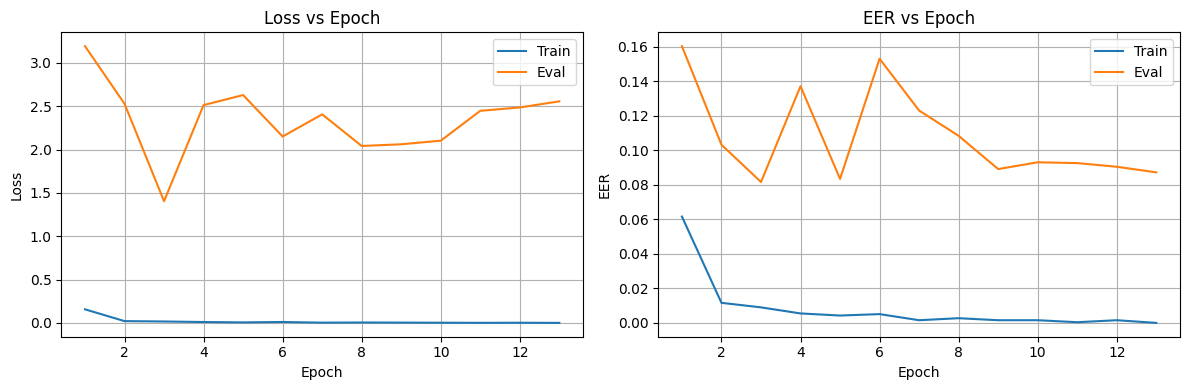

In [57]:
history = checkpoint['history']

epochs = range(1, len(history["train_loss"]) + 1)

plt.figure(figsize=(12, 4))

# Loss
plt.subplot(1, 2, 1)
plt.plot(epochs, history["train_loss"], label="Train")
plt.plot(epochs, history["eval_loss"], label="Eval")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss vs Epoch")
plt.legend()
plt.grid(True)

# EER
plt.subplot(1, 2, 2)
plt.plot(epochs, history["train_eer"], label="Train")
plt.plot(epochs, history["eval_eer"], label="Eval")
plt.xlabel("Epoch")
plt.ylabel("EER")
plt.title("EER vs Epoch")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

## XAI [See points below]

Let's analyse the model we have created. We won't be able to understand the differences easily without having some reference. So, we will use the novel idea from the recent [Interspeech 2025 paper](https://arxiv.org/abs/2506.03425).

We will use a [vocoded dataset](https://arxiv.org/abs/2210.10570) of parallel samples: real and fake audio have the same speaker saying the same content at the same time. The ground-truth explanation will be obtained by calculating difference between real and fake spectrograms.

In [61]:
# !wget https://zenodo.org/records/7314976/files/project09-voc.v4.tar?download=1 -O project09-voc.v4.tar
# !tar -xvf project09-voc.v4.tar

Note that real audio is taken from ASVspoof. So let's take a real example from the asvspoof dataset. Using its filename, find the corresponding `hifi-gan` and `waveglow` vocoded versions in the vocv4 and load them too

In reality, we are interested in the explanations for the unseen data. But for this homework, let's consider the train set. This will allow us to see if the model learns the futures we expect it to learn (assuming the XAI tool is trustworthy) (Though spoof part of vocv4 is not exactly the same as the one in asvspoof, so we mostly eliminate the issues related to changing speakers, not algorithms)

In [62]:
target_utt = "LA_T_4179989"

LA_cm_protocol[LA_cm_protocol['UtteranceID'] == target_utt]

,SpeakerID,UtteranceID,UtteranceType?,SpoofAlgoId,IsSpoofed
50,LA_0079,LA_T_4179989,-,-,bonafide


In [63]:
ind = 50 # for consistency with solutions choose the index that corresponds to LA_T_4179989 (bona fide)
real_path = 'asvpoof-2019-dataset/LA/LA/ASVspoof2019_LA_train/flac/LA_T_4179989.flac'
real_audio, real_sr = torchaudio.load(real_path)
real_audio = real_audio.mean(dim=0)

In [69]:
VOC_ROOT = "checkpoints/voc.v4/"

In [76]:
# get LCNN-prepared spectrogram for the paired real and fake example from the dataset
# paired: the same filename, but one is bona fide another is created via vocoder
from pathlib import Path

VOC_ROOT = Path("voc.v4/")

def _find_vocoded_file(utt_id: str, keyword: str) -> Path:
    patterns = [f"**/*{utt_id}*.wav", f"**/*{utt_id}*.flac"]
    cand = []
    for pat in patterns:
        cand.extend(VOC_ROOT.glob(pat))

    cand = [p for p in cand if keyword.lower() in str(p).lower()]
    if not cand:
        # fallback: если в путях нет keyword, просто возвращаем первый найденный файл
        cand = []
        for pat in patterns:
            cand.extend(VOC_ROOT.glob(pat))
        if not cand:
            raise FileNotFoundError(f"Не нашёл vocoded файл для {utt_id} внутри {VOC_ROOT}")
        return cand[0]

    # если несколько — берём самый короткий путь (часто более точное совпадение)
    cand = sorted(cand, key=lambda p: len(str(p)))
    return cand[0]


hifigan_path = _find_vocoded_file(target_utt, "hifi")
waveglow_path = _find_vocoded_file(target_utt, "waveglow")
print("real:", real_path)
print("hifigan:", hifigan_path)
print("waveglow:", waveglow_path)

hifigan_audio, hifigan_sr = torchaudio.load(str(hifigan_path))
hifigan_audio = hifigan_audio.mean(dim=0)

waveglow_audio, waveglow_sr = torchaudio.load(str(waveglow_path))
waveglow_audio = waveglow_audio.mean(dim=0)

real: asvpoof-2019-dataset/LA/LA/ASVspoof2019_LA_train/flac/LA_T_4179989.flac
hifigan: voc.v4/wav/hifigan_LA_T_4179989.wav
waveglow: voc.v4/wav/waveglow_LA_T_4179989.wav


In [77]:
import shutil

shutil.copy2(real_path, "working/real.wav")
shutil.copy2(hifigan_path, "working/hifigan.wav")
shutil.copy2(waveglow_path, "working/waveglow.wav")

'working/waveglow.wav'

In [78]:
# fake audio may be slightly longer due to padding, remove some part from the end to make the length equal
min_len = min(real_audio.numel(), hifigan_audio.numel(), waveglow_audio.numel())

# preprocess audio for model input
def single_preprocessing(path, min_len):
    """
    Переводим в stft
    """
    
    wav, sr = torchaudio.load(path)
    
    wav = wav[:min_len]
    
    if sr != SAMPLE_RATE:
        wav = F.resample(wav, sr, SAMPLE_RATE)

    wav = wav.mean(dim=0)

    spec = stft(wav)
    spec = torch.abs(spec)
    spec = torch.log(spec + 1e-6)
    spec = spec - spec.mean()
    
    if spec.size(1) < MAX_FRAMES:
        pad = MAX_FRAMES - spec.size(1)
        spec = torch.nn.functional.pad(spec, (0, pad))
    else:
        start = torch.randint(0, spec.size(1) - MAX_FRAMES + 1, (1,)).item()
        spec = spec[:, start:start+MAX_FRAMES]


    spec = spec.unsqueeze(0).unsqueeze(0) # [1, F, T]
    
    return spec

real_x = single_preprocessing(real_path, min_len)
hifigan_x = single_preprocessing(hifigan_path, min_len)
waveglow_x = single_preprocessing(waveglow_path, min_len)

print("real_x:", tuple(real_x.shape), "hifigan_x:", tuple(hifigan_x.shape), "waveglow_x:", tuple(waveglow_x.shape))

real_x: (1, 1, 257, 400) hifigan_x: (1, 1, 257, 400) waveglow_x: (1, 1, 257, 400)


Run your model on these clips. See if the model prediction is correct. Use this understanding for the following analysis

In [100]:
x = hifigan_x.to(device)
logits = model(x)
logits

tensor([[-7.2320,  7.0911]], device='cuda:0', grad_fn=<AddmmBackward0>)

In [101]:
x = waveglow_x.to(device)
logits = model(x)
logits

tensor([[-1.0005,  0.7842]], device='cuda:0', grad_fn=<AddmmBackward0>)

In [102]:
model.eval()

@torch.no_grad()
def _predict(x: torch.Tensor):
    x = x.to(device)
    logits = model(x)
    probs = torch.softmax(logits, dim=1).cpu().numpy().squeeze(0)  # [2]
    # порядок: [spoof, bona]
    return float(probs[0]), float(probs[1])

spoof_p, bona_p = _predict(real_x)
print(f"REAL    | spoof_p={spoof_p:.4f} bona_p={bona_p:.4f}")

spoof_p, bona_p = _predict(hifigan_x)
print(f"HIFIGAN | spoof_p={spoof_p:.4f} bona_p={bona_p:.4f}")

spoof_p, bona_p = _predict(waveglow_x)
print(f"WAVEGLOW| spoof_p={spoof_p:.4f} bona_p={bona_p:.4f}")

REAL    | spoof_p=0.0000 bona_p=1.0000
HIFIGAN | spoof_p=0.0000 bona_p=1.0000
WAVEGLOW| spoof_p=0.1437 bona_p=0.8563


### Manual explanation [0.5 pts]

Compare the two spectrograms (real and fake). What differences do you see? (**Hint**: they exist, if you do not see -- look carefully).

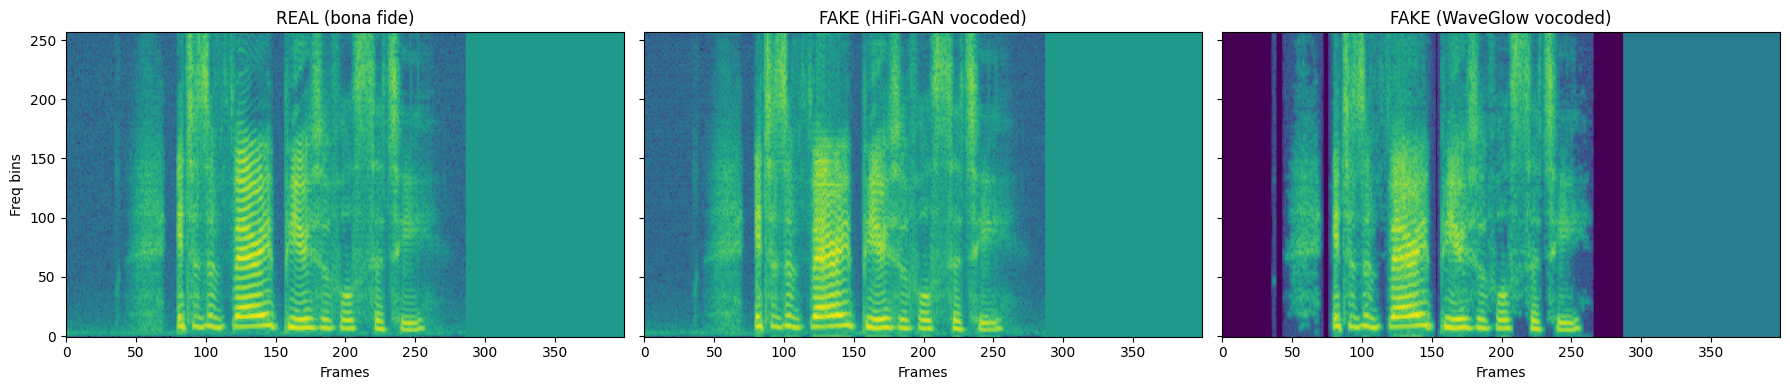

In [103]:
real_spec = real_x.squeeze(0).squeeze(0).cpu().numpy()      # [F, T]
hifigan_spec = hifigan_x.squeeze(0).squeeze(0).cpu().numpy()
waveglow_spec = waveglow_x.squeeze(0).squeeze(0).cpu().numpy()

fig, axes = plt.subplots(1, 3, figsize=(18, 4), sharey=True)

axes[0].imshow(real_spec, origin="lower", aspect="auto")
axes[0].set_title("REAL (bona fide)")
axes[0].set_xlabel("Frames")
axes[0].set_ylabel("Freq bins")

axes[1].imshow(hifigan_spec, origin="lower", aspect="auto")
axes[1].set_title("FAKE (HiFi-GAN vocoded)")
axes[1].set_xlabel("Frames")

axes[2].imshow(waveglow_spec, origin="lower", aspect="auto")
axes[2].set_title("FAKE (WaveGlow vocoded)")
axes[2].set_xlabel("Frames")

plt.tight_layout()
plt.show()

**Your answer here**

Fake выглядит более сглаженной

### Automatic explanation. [0.5 pts]

Calculate Eq. 2 from the [Interspeech 2025 paper](https://arxiv.org/abs/2506.03425) to automatically highlight the differences between two objects

In [104]:
from scipy.ndimage import gaussian_filter

def compute_mask(spec_fake, spec_real):
    """
    Спектрограмма: [1, F, T]
    """
    # Убираем batch dim
    spec_fake = spec_fake.squeeze(0).squeeze(0).numpy()
    spec_real = spec_real.squeeze(0).squeeze(0).numpy()
    
    # Gaussian smoothing: (time, freq) = (11,3) в scipy order
    # В scipy: sigma=(freq, time)
    sigma = (3, 5)  # частота, время
    smooth_fake = gaussian_filter(spec_fake, sigma=sigma)
    smooth_real = gaussian_filter(spec_real, sigma=sigma)
    
    # Нормализация по real
    mask = abs(smooth_fake - smooth_real) / (abs(smooth_real) + 1e-6)
    
    # Бинаризация (threshold можно подбирать)
    mask_bin = (mask > 0.3).astype(float)
    
    return mask_bin

Plot the mask on top of the fake spectrogram and compare three plots: real, fake, fake+mask on top. Do it for both vocoders. Compare

In [105]:
def plot_spectrogram_with_mask(spec_fake, mask, title="Fake + Mask"):
    """
    spec_fake: [1, F, T]
    mask: [F, T] бинарная маска
    """
    spec_fake = spec_fake.squeeze(0).squeeze(0).numpy()
    
    plt.figure(figsize=(12, 4))
    
    plt.subplot(1,3,1)
    plt.title("Real")
    plt.imshow(real_x.squeeze(0).squeeze(0).numpy(), origin="lower", aspect="auto", cmap="viridis")
    plt.colorbar()
    
    plt.subplot(1,3,2)
    plt.title(title.replace("+ Mask",""))
    plt.imshow(spec_fake, origin="lower", aspect="auto", cmap="viridis")
    plt.colorbar()
    
    plt.subplot(1,3,3)
    plt.title(title)
    plt.imshow(spec_fake, origin="lower", aspect="auto", cmap="viridis")
    plt.imshow(mask, origin="lower", aspect="auto", cmap="Reds", alpha=0.6)  # красная маска сверху
    plt.colorbar()
    
    plt.tight_layout()
    plt.show()

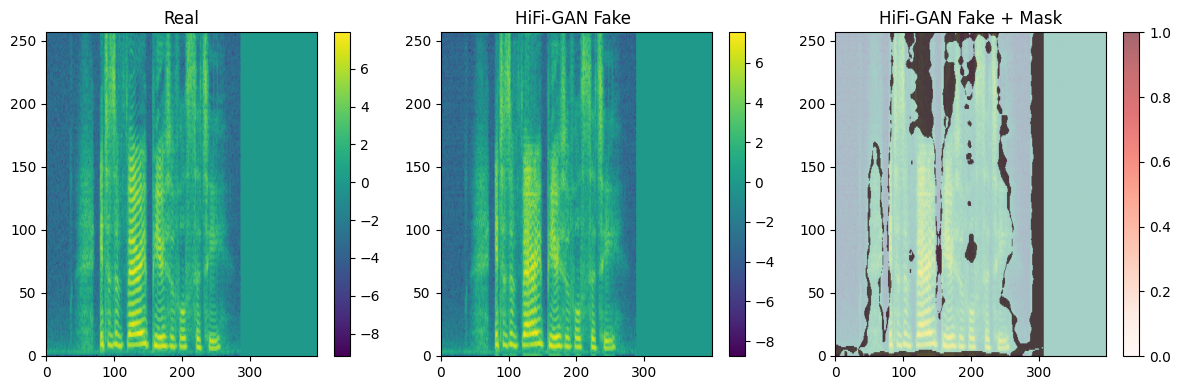

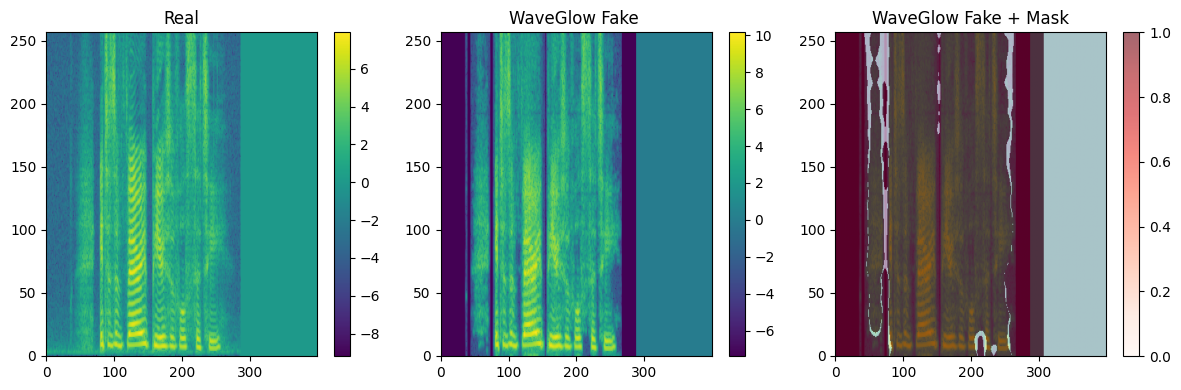

In [106]:
mask_hifi = compute_mask(hifigan_x, real_x)
plot_spectrogram_with_mask(hifigan_x, mask_hifi, title="HiFi-GAN Fake + Mask")

mask_wave = compute_mask(waveglow_x, real_x)
plot_spectrogram_with_mask(waveglow_x, mask_wave, title="WaveGlow Fake + Mask")

**Your comparison of the ground-truth mask with your manual analysis (from previous subtask) here**

### Grad-CAM [0.5 pts]

Using [pytorch-grad-cam lib](https://github.com/jacobgil/pytorch-grad-cam), implement [Grad-CAM](https://arxiv.org/abs/1610.02391) for your LCNN model. Choose the layer you like

In [107]:
# grad-cam and captum may have conflicting numpy dependencies. Just install grad-cam first, then captum and it will work

In [109]:
# !pip install grad-cam

In [110]:
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

target_class = 1
target_layer = model.conv5

cam = GradCAM(model=model, target_layers=[target_layer])

In [111]:
grayscale_cam = cam(input_tensor=hifigan_x, 
                    targets=[ClassifierOutputTarget(target_class)])

# grayscale_cam shape: [batch_size, F, T], values 0..1
grayscale_cam = grayscale_cam[0]

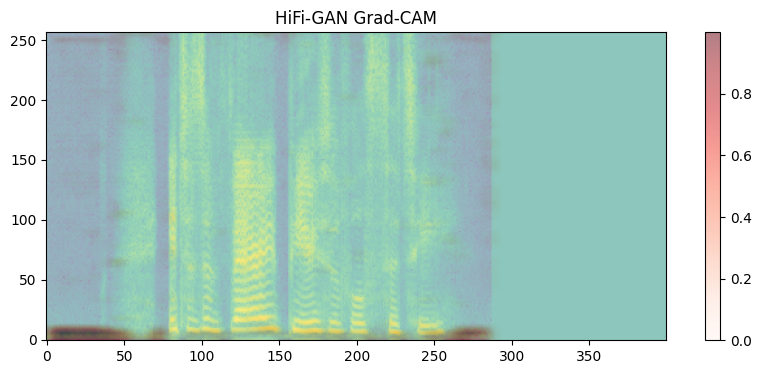

In [112]:
def plot_cam_on_spectrogram(spec, cam_map, title="Grad-CAM"):
    """
    spec: [1, 1, F, T] STFT
    cam_map: [F, T] grayscale 0..1
    """
    spec = spec.squeeze(0).squeeze(0).cpu().numpy()
    # cam_map = cam_map.cpu().numpy()
    
    plt.figure(figsize=(10,4))
    plt.imshow(spec, origin='lower', aspect='auto', cmap='viridis')
    plt.imshow(cam_map, origin='lower', aspect='auto', cmap='Reds', alpha=0.5)
    plt.title(title)
    plt.colorbar()
    plt.show()

plot_cam_on_spectrogram(hifigan_x, grayscale_cam, title="HiFi-GAN Grad-CAM")

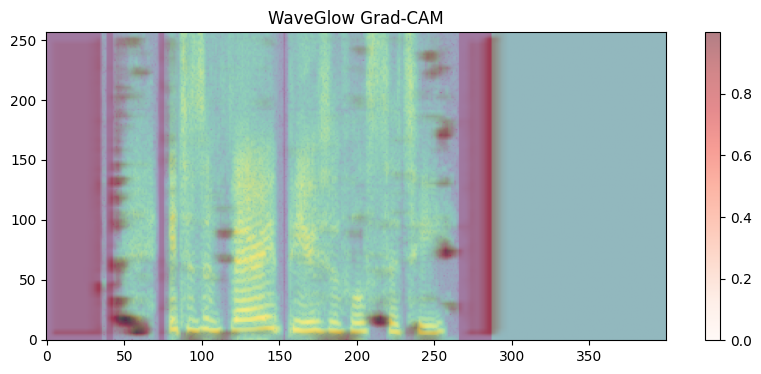

In [113]:
grayscale_cam_wave = cam(input_tensor=waveglow_x, targets=[ClassifierOutputTarget(target_class)])
plot_cam_on_spectrogram(waveglow_x, grayscale_cam_wave[0], title="WaveGlow Grad-CAM")

### Comparison [1.0 pts]

Compare your Grad-CAM attributions with another gradient-based method: InputXGradient. Compute it using [Captum](https://captum.ai/).

In [127]:
# !pip install captum

In [115]:
from captum.attr import InputXGradient

model.eval()
ixg = InputXGradient(model)

In [116]:
inputs = hifigan_x
attributions = ixg.attribute(inputs.to(device), target=target_class)
# shape: [1, 1, F, T]
attributions = attributions.squeeze(0).squeeze(0).cpu().detach().numpy()

/home/maksimkrug/projects/stepik_audio/DLSSpeechCourse/.venv/lib/python3.12/site-packages/captum/attr/_core/input_x_gradient.py:118: UserWarning: Input Tensor 0 did not already require gradients, required_grads has been set automatically.
  gradient_mask = apply_gradient_requirements(inputs_tuple)


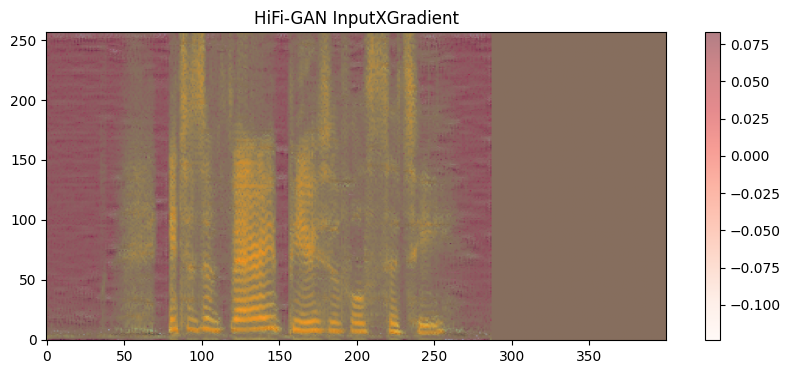

In [117]:
def plot_attribution(spec, attr, title="InputXGradient"):
    spec = spec.squeeze(0).squeeze(0).detach().cpu().numpy()
    
    plt.figure(figsize=(10,4))
    plt.imshow(spec, origin='lower', aspect='auto', cmap='viridis')
    plt.imshow(attr, origin='lower', aspect='auto', cmap='Reds', alpha=0.5)
    plt.title(title)
    plt.colorbar()
    plt.show()

plot_attribution(hifigan_x, attributions, title="HiFi-GAN InputXGradient")

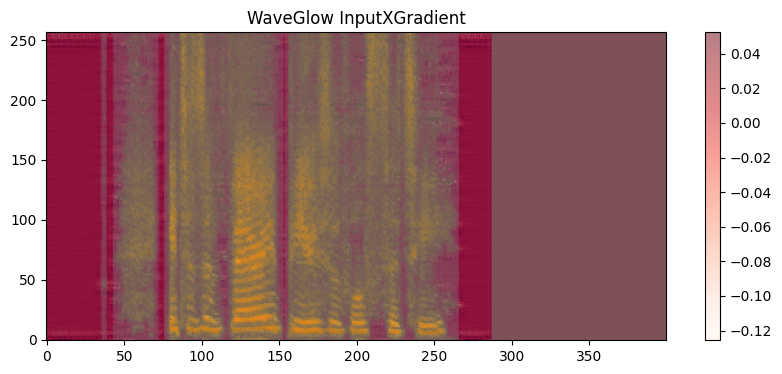

In [118]:
inputs = waveglow_x
attributions_wave = ixg.attribute(inputs.to(device), target=target_class)
attributions_wave = attributions_wave.squeeze(0).squeeze(0).cpu().detach().numpy()

plot_attribution(waveglow_x, attributions_wave, title="WaveGlow InputXGradient")

Do three plots: mask vs grad-cam vs inputXgradient. Compare them. Does any of the XAI methods align with the mask?

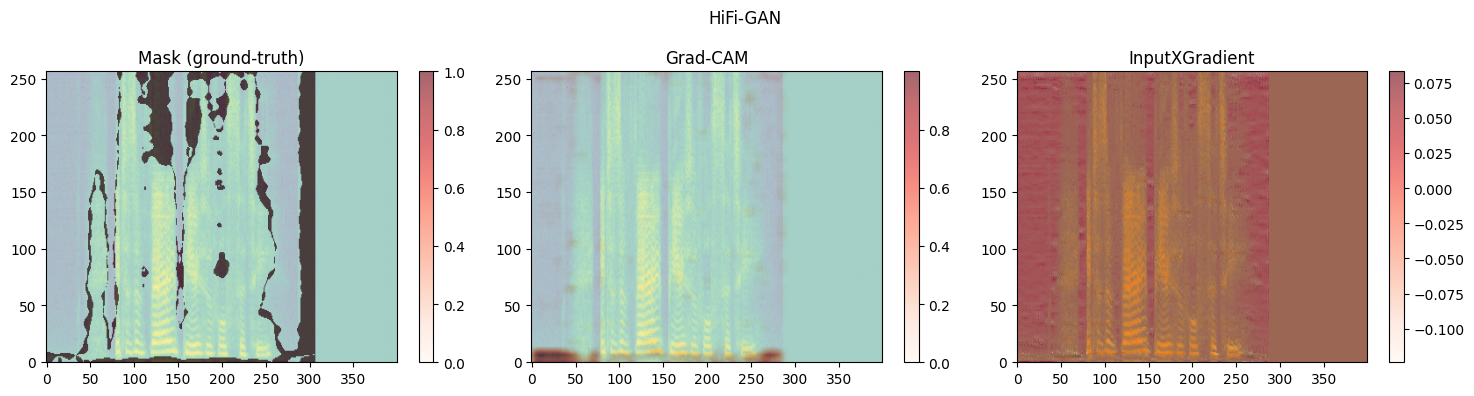

In [119]:
hifigan_x_ = hifigan_x.squeeze(0).squeeze(0).detach().cpu().numpy()
    
plt.figure(figsize=(15, 4))

plt.subplot(1,3,1)
plt.title("Mask (ground-truth)")
plt.imshow(hifigan_x_, origin='lower', aspect='auto', cmap='viridis')
plt.imshow(mask_hifi, origin='lower', aspect='auto', cmap='Reds', alpha=0.6)
plt.colorbar()

plt.subplot(1,3,2)
plt.title("Grad-CAM")
plt.imshow(hifigan_x_, origin='lower', aspect='auto', cmap='viridis')
plt.imshow(grayscale_cam, origin='lower', aspect='auto', cmap='Reds', alpha=0.6)
plt.colorbar()

# 3. InputXGradient
plt.subplot(1,3,3)
plt.title("InputXGradient")
plt.imshow(hifigan_x_, origin='lower', aspect='auto', cmap='viridis')
plt.imshow(attributions, origin='lower', aspect='auto', cmap='Reds', alpha=0.6)
plt.colorbar()

plt.suptitle("HiFi-GAN")
plt.tight_layout()
plt.show()

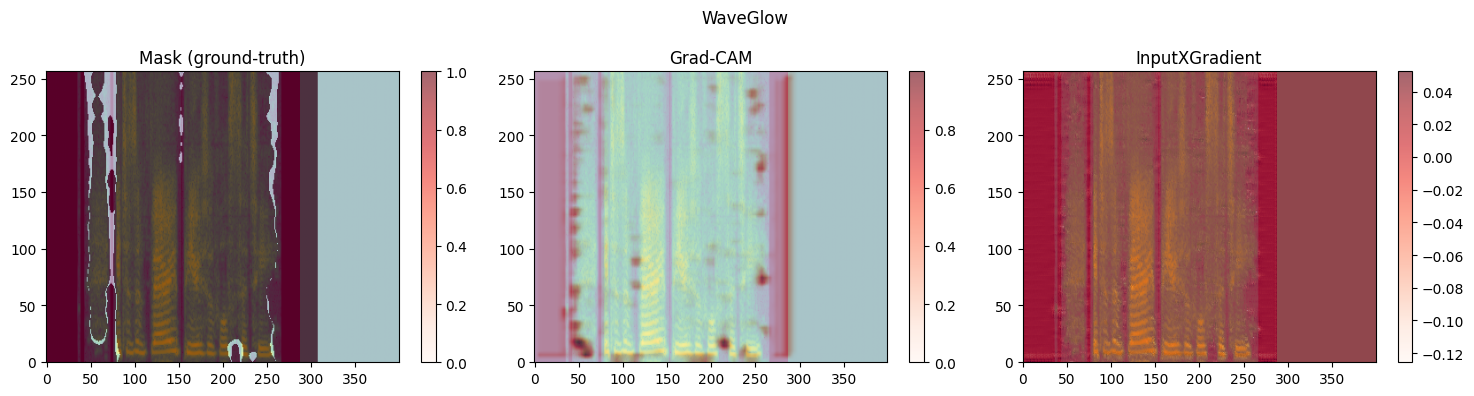

In [120]:
waveglow_x_ = waveglow_x.squeeze(0).squeeze(0).detach().cpu().numpy()
    
plt.figure(figsize=(15, 4))

# 1. Mask
plt.subplot(1,3,1)
plt.title("Mask (ground-truth)")
plt.imshow(waveglow_x_, origin='lower', aspect='auto', cmap='viridis')
plt.imshow(mask_wave, origin='lower', aspect='auto', cmap='Reds', alpha=0.6)
plt.colorbar()

# 2. Grad-CAM
plt.subplot(1,3,2)
plt.title("Grad-CAM")
plt.imshow(waveglow_x_, origin='lower', aspect='auto', cmap='viridis')
plt.imshow(grayscale_cam_wave[0], origin='lower', aspect='auto', cmap='Reds', alpha=0.6)
plt.colorbar()

# 3. InputXGradient
plt.subplot(1,3,3)
plt.title("InputXGradient")
plt.imshow(waveglow_x_, origin='lower', aspect='auto', cmap='viridis')
plt.imshow(attributions_wave, origin='lower', aspect='auto', cmap='Reds', alpha=0.6)
plt.colorbar()

plt.suptitle("WaveGlow")
plt.tight_layout()
plt.show()

**Your answer here**

Due to skewed distribution for some XAI tools, you may want to look at top-5% points, similarly to the ground-truth mask. Binarize attributions using their $95\%$ quantile and plot again:

In [123]:
def binarize_attribution(attr, quantile=0.95):
    """
    Binarize attribution by its top quantile.
    attr: np.array [F, T]
    quantile: e.g., 0.95 for top 5%
    """
    threshold = np.quantile(attr, quantile)
    return (attr >= threshold).astype(float)

gradcam_hifi_bin = binarize_attribution(grayscale_cam, 0.95)
ixg_hifi_bin = binarize_attribution(attributions, 0.95)

gradcam_wave_bin = binarize_attribution(grayscale_cam_wave[0], 0.95)
ixg_wave_bin = binarize_attribution(attributions_wave, 0.95)

In [124]:
def compare_mask_xai(spec_fake, mask, gradcam_bin, ixg_bin, title_prefix):
    spec_fake = spec_fake.squeeze(0).squeeze(0).detach().cpu().numpy()
    
    plt.figure(figsize=(15, 4))
    
    # Mask
    plt.subplot(1,3,1)
    plt.title("Mask (ground-truth)")
    plt.imshow(spec_fake, origin='lower', aspect='auto', cmap='viridis')
    plt.imshow(mask, origin='lower', aspect='auto', cmap='Reds', alpha=0.6)
    plt.colorbar()
    
    # Grad-CAM binarized
    plt.subplot(1,3,2)
    plt.title("Grad-CAM (top 5%)")
    plt.imshow(spec_fake, origin='lower', aspect='auto', cmap='viridis')
    plt.imshow(gradcam_bin, origin='lower', aspect='auto', cmap='Reds', alpha=0.6)
    plt.colorbar()
    
    # InputXGradient binarized
    plt.subplot(1,3,3)
    plt.title("InputXGradient (top 5%)")
    plt.imshow(spec_fake, origin='lower', aspect='auto', cmap='viridis')
    plt.imshow(ixg_bin, origin='lower', aspect='auto', cmap='Reds', alpha=0.6)
    plt.colorbar()
    
    plt.suptitle(title_prefix)
    plt.tight_layout()
    plt.show()

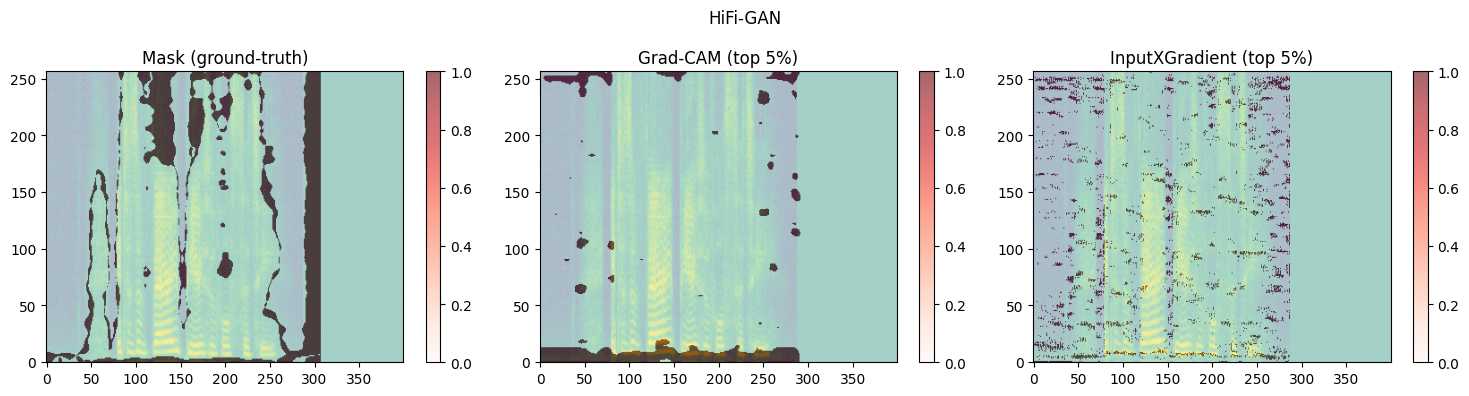

In [125]:
compare_mask_xai(hifigan_x, mask_hifi, gradcam_hifi_bin, ixg_hifi_bin, title_prefix="HiFi-GAN")

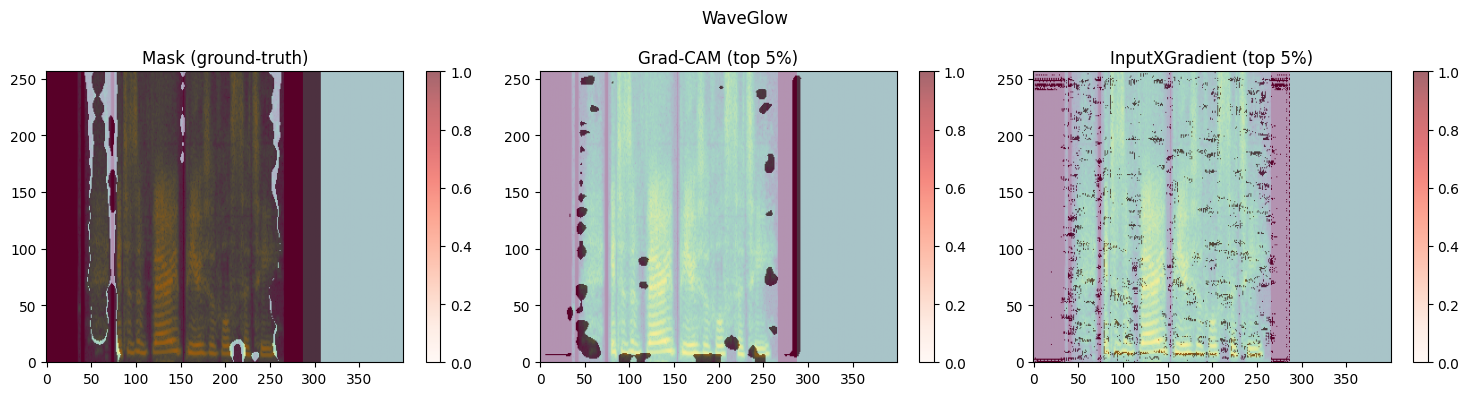

In [126]:
compare_mask_xai(waveglow_x, mask_wave, gradcam_wave_bin, ixg_wave_bin, title_prefix="WaveGlow")

**Your analysis here**